# Synthetic Hospital Readmission Dataset

This notebook creates a synthetic dataset for the Hospital Readmission Prediction case study.

The dataset contains patient demographic information, vital signs, previous hospital visits, diagnosis-related information, and a target variable indicating whether the patient was readmitted within 30 days.

> **Note:** This is synthetic data created for educational purposes. It does not represent real patient records.


#Cell 2 — Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Set random seed so the results are reproducible
np.random.seed(42)

#Cell 3 — Set Number of Patients

In [2]:
# Number of synthetic patient records
n = 10000

print("Number of patients:", n)


Number of patients: 10000


#Step 4 — Generate Patient Demographics

Cell 4 — Age

In [3]:
# Generate patient ages between 18 and 90
age = np.random.randint(18, 91, n)

print(age[:10])

[69 32 89 78 38 41 20 39 70 19]


Cell 5 — Gender

In [4]:
# Generate gender
gender = np.random.choice(
    ["Male", "Female"],
    size=n
)

print(gender[:10])

['Male' 'Male' 'Male' 'Male' 'Female' 'Female' 'Male' 'Female' 'Female'
 'Male']


#Step 5 — Generate Vital Signs

These variables are included because your case study mentions vitals.

#Cell 6 — Heart Rate

In [5]:
# Heart rate in beats per minute
heart_rate = np.random.normal(
    loc=78,
    scale=12,
    size=n
).round(0)

print(heart_rate[:10])

[68. 86. 76. 73. 68. 69. 82. 62. 90. 72.]


#Cell 7 — Blood Pressure

In [6]:
# Systolic blood pressure
systolic_bp = np.random.normal(
    loc=125,
    scale=18,
    size=n
).round(0)

# Diastolic blood pressure
diastolic_bp = np.random.normal(
    loc=80,
    scale=10,
    size=n
).round(0)

print("Systolic BP:", systolic_bp[:10])
print("Diastolic BP:", diastolic_bp[:10])

Systolic BP: [101. 120. 139. 150. 120. 113. 131. 106. 122. 125.]
Diastolic BP: [73. 81. 95. 80. 67. 81. 88. 79. 93. 89.]


#Cell 8 — Temperature

In [7]:
# Body temperature in Fahrenheit
temperature = np.random.normal(
    loc=98.2,
    scale=0.8,
    size=n
).round(1)

print(temperature[:10])

[98.7 98.6 97.9 99.7 97.8 96.9 98.8 97.1 98.3 99.3]


#Cell 9 — Oxygen Saturation

In [8]:
# Oxygen saturation percentage
oxygen_saturation = np.random.normal(
    loc=97,
    scale=2,
    size=n
).round(1)

print(oxygen_saturation[:10])

[ 96.2  96.6  92.3 100.4  97.2  99.7  94.2  97.2  97.8  97.3]


#Step 6 — Generate Previous Hospital Visits

These variables represent the patient’s previous healthcare utilization.

In [9]:
# Number of previous outpatient visits
num_prior_visits = np.random.poisson(
    lam=2,
    size=n
)

# Number of previous emergency visits
num_emergency_visits = np.random.poisson(
    lam=1,
    size=n
)

# Number of previous inpatient visits
num_inpatient_visits = np.random.poisson(
    lam=1,
    size=n
)

print("Prior visits:", num_prior_visits[:10])
print("Emergency visits:", num_emergency_visits[:10])
print("Inpatient visits:", num_inpatient_visits[:10])

Prior visits: [0 3 4 5 3 6 1 4 1 0]
Emergency visits: [1 1 0 3 0 0 1 0 0 1]
Inpatient visits: [1 0 2 2 2 3 1 2 2 0]


#Step 7 — Generate Diagnosis Information

#Cell 11 — Number of Diagnoses

In [10]:
# Number of diagnoses recorded for the patient
num_diagnoses = np.random.randint(
    1,
    10,
    n
)

print(num_diagnoses[:10])

[1 8 9 3 7 6 3 3 3 9]


#Step 8 — Generate Hospital Stay

#Cell 12 — Length of Stay

In [11]:
# Length of hospital stay in days
length_of_stay = np.random.randint(
    1,
    15,
    n
)

print(length_of_stay[:10])

[13  4  7  5  1  1 12  8 13  2]


#Step 9 — Generate Medical Conditions

# Cell 13 — Diabetes

In [12]:
# 0 = No diabetes
# 1 = Diabetes

diabetes = np.random.choice(
    [0, 1],
    size=n,
    p=[0.70, 0.30]
)

print(pd.Series(diabetes).value_counts())

0    7002
1    2998
Name: count, dtype: int64


#Cell 14 — Hypertension

In [13]:
# 0 = No hypertension
# 1 = Hypertension

hypertension = np.random.choice(
    [0, 1],
    size=n,
    p=[0.60, 0.40]
)

print(pd.Series(hypertension).value_counts())

0    5979
1    4021
Name: count, dtype: int64


#Step 10 — Previous Readmission

This is an important predictor.

#Cell 15

In [14]:
# 0 = No previous readmission
# 1 = Previous readmission

previous_readmission = np.random.choice(
    [0, 1],
    size=n,
    p=[0.75, 0.25]
)

print(pd.Series(previous_readmission).value_counts())

0    7474
1    2526
Name: count, dtype: int64


#Step 11 — Create Readmission Risk

Now we create the 30-day readmission risk.

This is where we make the synthetic data somewhat realistic.

Patients with factors such as:

* Older age
* More previous visits
* More emergency visits
* More inpatient visits
* More diagnoses
* Longer hospital stays
* Previous readmission

will generally have higher readmission risk.

In [15]:
risk_score = (
    -3.0
    + 0.015 * age
    + 0.08 * num_prior_visits
    + 0.15 * num_emergency_visits
    + 0.20 * num_inpatient_visits
    + 0.12 * num_diagnoses
    + 0.04 * length_of_stay
    + 0.50 * diabetes
    + 0.40 * hypertension
    + 1.00 * previous_readmission
    + 0.02 * (heart_rate - 75)
    + 0.01 * (systolic_bp - 120)
)

#Step 12 — Convert Risk Score to Probability

Logistic regression uses probabilities between 0 and 1.

#Cell 17

In [16]:
probability = 1 / (1 + np.exp(-risk_score))

print(probability[:10])

[0.42433565 0.75212911 0.73594539 0.67699586 0.2592251  0.41702455
 0.2350522  0.37402214 0.77381857 0.52123721]


#Step 13 — Generate the Target Variable

Now we’ll generate whether each patient was actually readmitted.

#Cell 18

In [18]:
readmitted_30_days = np.random.binomial(
    1,
    probability
)

print(readmitted_30_days[:20])

[0 1 0 1 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0]


#Step 14 — Create the DataFrame

Now put everything together.

#Cell 19

In [19]:
df = pd.DataFrame({
    "age": age,
    "gender": gender,
    "heart_rate": heart_rate,
    "systolic_bp": systolic_bp,
    "diastolic_bp": diastolic_bp,
    "temperature": temperature,
    "oxygen_saturation": oxygen_saturation,
    "num_prior_visits": num_prior_visits,
    "num_emergency_visits": num_emergency_visits,
    "num_inpatient_visits": num_inpatient_visits,
    "num_diagnoses": num_diagnoses,
    "length_of_stay": length_of_stay,
    "diabetes": diabetes,
    "hypertension": hypertension,
    "previous_readmission": previous_readmission,
    "readmitted_30_days": readmitted_30_days
})

df.head()

,age,gender,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
0,69,Male,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,0
1,32,Male,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,1
2,89,Male,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,0
3,78,Male,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,1
4,38,Female,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,0


#Step 15 — Check Dataset Shape

#Cell 20

In [20]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 16


#Step 16 — Check Column Names

#Cell 21

In [22]:
print(df.columns.tolist())

['age', 'gender', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'temperature', 'oxygen_saturation', 'num_prior_visits', 'num_emergency_visits', 'num_inpatient_visits', 'num_diagnoses', 'length_of_stay', 'diabetes', 'hypertension', 'previous_readmission', 'readmitted_30_days']


#Step 17 — Check Data Information

#Cell 22

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   gender                10000 non-null  object 
 2   heart_rate            10000 non-null  float64
 3   systolic_bp           10000 non-null  float64
 4   diastolic_bp          10000 non-null  float64
 5   temperature           10000 non-null  float64
 6   oxygen_saturation     10000 non-null  float64
 7   num_prior_visits      10000 non-null  int64  
 8   num_emergency_visits  10000 non-null  int64  
 9   num_inpatient_visits  10000 non-null  int64  
 10  num_diagnoses         10000 non-null  int64  
 11  length_of_stay        10000 non-null  int64  
 12  diabetes              10000 non-null  int64  
 13  hypertension          10000 non-null  int64  
 14  previous_readmission  10000 non-null  int64  
 15  readmitted_30_days  

#Step 18 — Check Missing Values

#Cell 23

In [24]:
print(df.isnull().sum())

age                     0
gender                  0
heart_rate              0
systolic_bp             0
diastolic_bp            0
temperature             0
oxygen_saturation       0
num_prior_visits        0
num_emergency_visits    0
num_inpatient_visits    0
num_diagnoses           0
length_of_stay          0
diabetes                0
hypertension            0
previous_readmission    0
readmitted_30_days      0
dtype: int64


#Step 19 — Check Statistics

#Cell 24

In [25]:
df.describe()

,age,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.018800,78.139500,124.892900,79.921000,98.203170,97.005610,1.988500,0.99440,1.02380,4.977600,7.545200,0.299800,0.402100,0.252600,0.474300
std,21.051422,12.061848,17.825757,10.022964,0.801406,2.022893,1.406544,1.00313,1.01328,2.560577,4.039949,0.458193,0.490346,0.434525,0.499364
min,18.000000,32.000000,59.000000,35.000000,94.800000,88.700000,0.000000,0.00000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,70.000000,113.000000,73.000000,97.700000,95.600000,1.000000,0.00000,0.00000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,78.000000,125.000000,80.000000,98.200000,97.000000,2.000000,1.00000,1.00000,5.000000,8.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,86.000000,137.000000,87.000000,98.700000,98.400000,3.000000,2.00000,2.00000,7.000000,11.000000,1.000000,1.000000,1.000000,1.000000
max,90.000000,132.000000,191.000000,117.000000,101.000000,104.500000,12.000000,7.00000,7.00000,9.000000,14.000000,1.000000,1.000000,1.000000,1.000000


#Step 20 — Check Target Distribution

#Cell 25

In [26]:
print(df["readmitted_30_days"].value_counts())

readmitted_30_days
0    5257
1    4743
Name: count, dtype: int64


In [27]:
print(
    df["readmitted_30_days"]
    .value_counts(normalize=True) * 100
)

readmitted_30_days
0    52.57
1    47.43
Name: proportion, dtype: float64


#Step 21 — Visualize Readmission Distribution

#Cell 26

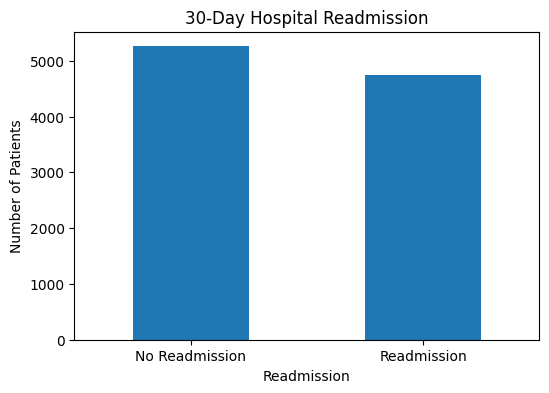

In [32]:
df["readmitted_30_days"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("30-Day Hospital Readmission")
plt.xlabel("Readmission")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["No Readmission", "Readmission"],
    rotation=0
)

plt.show()

#Step 22 — Save the Dataset
Finally, save the dataset as a CSV.

#Cell 27

In [33]:
df.to_csv(
    "hospital_readmission.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


#Step 23 — Verify the CSV

In [34]:
new_df = pd.read_csv("hospital_readmission.csv")

print(new_df.shape)

new_df.head()

(10000, 16)


,age,gender,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
0,69,Male,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,0
1,32,Male,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,1
2,89,Male,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,0
3,78,Male,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,1
4,38,Female,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,0
